# Random Processes and Monte Carlo Methods

See examples/probabilty_example.ipynb for an example of how to use random number generation to model probabilities.

**Authorship information:** Parts 1 and 2 of this notebook were written by the instructor with some assistance by Github Copilot (autocomplete). Part 3 was developed iteratively with Claude.ai, a large language model, for PHY 225 taught by Prof. Bryanne McDonough. The LLM was asked to develop a problem that combined radioactive decay and random walks. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes. Please raise an issue on the upstream GitHub repository (the one you forked) if you find a problem.

## Grading

Note that for this assignment there are three parts. To achieve a good grade on this assignment, it is only necessary to complete parts 1 and 2. However, to earn a score of 'Advanced', you must also complete Part 3. If you find that Parts 1 and 2 take you a long time, it might be better to skip Part 3 and work on your projects instead.

Your assignment will be graded on the following scale:
- **No Evidence** — assignment not completed or submitted
- **Beginning** — some effort, but significant errors or omissions
- **Emerging** — mostly correct, but with some errors or omissions
- **Proficient** — correct and complete, with clear explanations (Parts 1 and 2 complete)
- **Advanced** — correct, complete, and demonstrates deeper understanding (Part 3 completed in addition to parts 1 and 2)


## Part 1: Radioactive Decay
The radioisotope Carbon-14 decays with a half-life of 5730 years. This means that if you start with a sample of Carbon-14, after 5730 years, only half of the original sample will remain. The decay product is Nitrogen-14, which is stable.

The number of Carbon-14 atoms remaining after time *t* can be modeled as an exponential decay process:
$$
N(t) = N_0 2^{-t/\tau},
$$
where $N_0$ is the initial number of Carbon-14 atoms and $\tau$ is the half-life.

The fraction of C14 atoms remaining after some time *t* can be calculated as: $\frac{N(t)}{N_0} = 2^{-t/\tau}$. Thus, the fraction of C14 atoms that have decayed is $1 - 2^{-t/\tau}$. This is then the probability for an individual C14 atom to have decayed:
$$
p=  1 - 2^{-t/\tau}
$$


### Exercise 1: Simulating Radioactive Decay
Write a program which does the following:
1. Starts with a sample of 1000 Carbon-14 atoms and 0 Nitrogen-14 atoms.
2. Iterates over 50,000 years in increments of 1,000 years.
3. At each time step, iterate (or use vector operations) over each remaining C14 atom to determine whether or not it decays. 
4. At each timestep, update the counts of C14 and N14 atoms accordingly.
5. Plots the number of C14 and N14 atoms as a function of time.

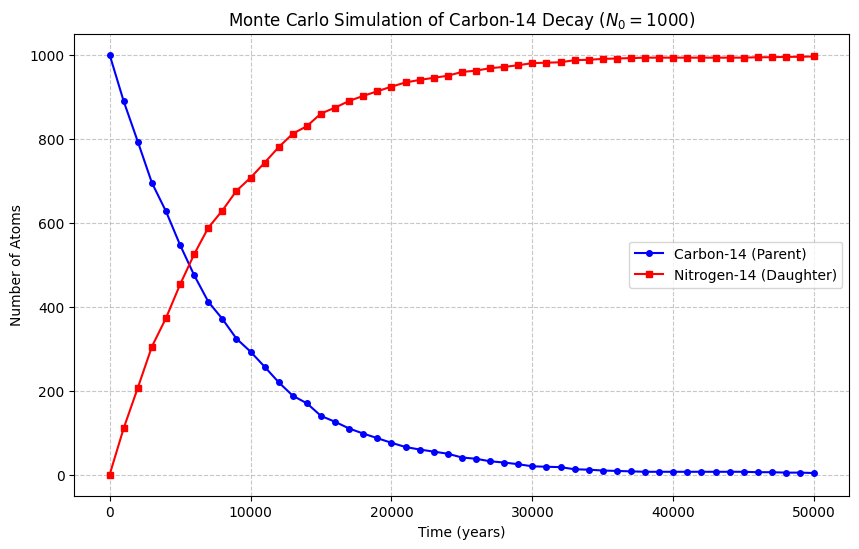

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
N_initial = 1000       
half_life = 5730       
dt = 1000              
total_time = 50000     

times = np.arange(0, total_time + dt, dt)
c14_counts = np.zeros(len(times))
n14_counts = np.zeros(len(times))

current_c14 = N_initial
current_n14 = 0

# Probability an individual atom decays during one time step dt
p_decay = 1 - 2**(-dt / half_life)

for i, t in enumerate(times):
    c14_counts[i] = current_c14
    n14_counts[i] = current_n14
    
    # Monte Carlo step: roll the dice for each remaining C14 atom
    decays = np.random.random(int(current_c14)) < p_decay
    num_decays = np.sum(decays)
    
    # Update populations
    current_c14 -= num_decays
    current_n14 += num_decays

# Visualize the results
plt.figure(figsize=(10, 6))
plt.plot(times, c14_counts, label='Carbon-14 (Parent)', color='blue', marker='o', markersize=4)
plt.plot(times, n14_counts, label='Nitrogen-14 (Daughter)', color='red', marker='s', markersize=4)

plt.title(f"Monte Carlo Simulation of Carbon-14 Decay ($N_0={N_initial}$)")
plt.xlabel("Time (years)")
plt.ylabel("Number of Atoms")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Part 2: Random Walks
Brownian motion is the random movement of particles suspended in a fluid (liquid or gas) resulting from their collision with the fast-moving molecules in the fluid. This phenomenon can be modeled as a random walk, where a particle takes steps in random directions at each time step. In a simple 2D random walk, a particle can move up, down, left, or right with equal probability.

### Exercise 2: Simulating a 2D Random Walk
Write a program that simulates a 2D random walk of a single particle. The program should:
1. Set up a grid of L x L points (e.g., L=101, you will want an odd number so there is a center point). The particle is initially located at the center of the grid and must stay within the bounds of the grid.
2. At each step, use a  random number generator to randomly choose a direction (up, down, left, right) and move the particle one unit in that direction. If the move would make the particle go out of bounds, ignore that move and choose another random direction.
3. Repeat this process for a large number of steps (e.g., 10,000 steps).
4. After the simulation, plot the trajectory of the particle on the grid.
    - Make sure your plot has labeled axes
    - Make sure your plot includes the trajectory and clearly labeled points for the starting and ending positions of the particle.
    - When you plot the trajectory, use the linewidth parameter to make the line thinner (lw=0.4), so the plot is easier to read. You may also want to reduce the opacity (using alpha=0.5).



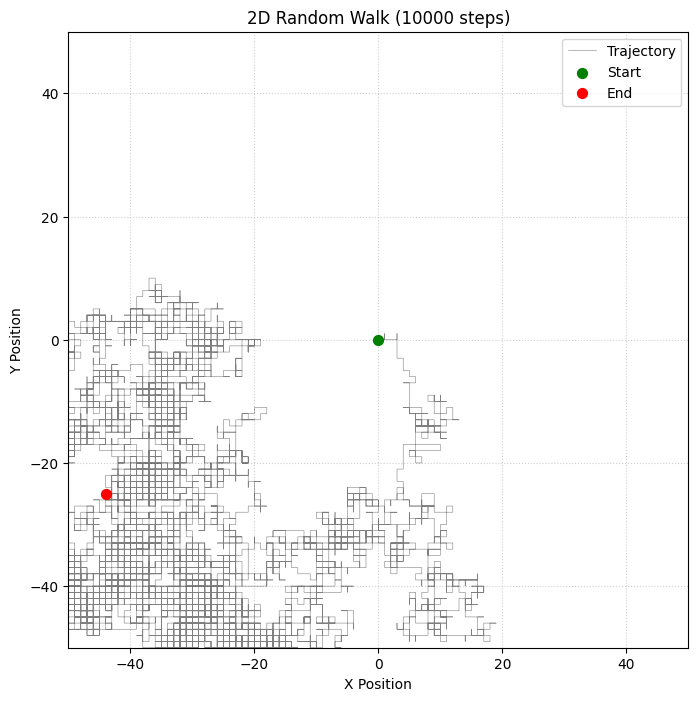

In [18]:
# write your random walk code here
import numpy as np
import matplotlib.pyplot as plt

L = 101
steps = 10000
limit = L // 2  

x, y = [0], [0]
moves = [(0, 1), (0, -1), (-1, 0), (1, 0)]

while len(x) < steps:
    dx, dy = moves[np.random.randint(0, 4)]
    
    new_x = x[-1] + dx
    new_y = y[-1] + dy
    
    # Only update if the particle remains within the L x L grid
    if -limit <= new_x <= limit and -limit <= new_y <= limit:
        x.append(new_x)
        y.append(new_y)

plt.figure(figsize=(8, 8))

# Styling with low linewidth and alpha as requested
plt.plot(x, y, lw=0.4, alpha=0.5, color='black', label='Trajectory')

plt.scatter(x[0], y[0], color='green', s=50, label='Start', zorder=5)
plt.scatter(x[-1], y[-1], color='red', s=50, label='End', zorder=5)

plt.title(f"2D Random Walk ({steps} steps)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

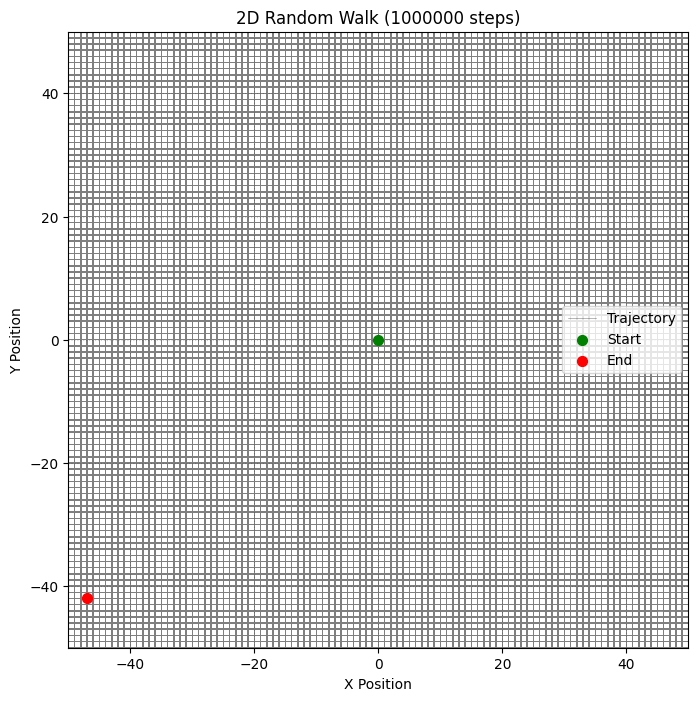

In [19]:
# write your random walk code here
import numpy as np
import matplotlib.pyplot as plt

L = 101
steps = 1000000
limit = L // 2  

x, y = [0], [0]
moves = [(0, 1), (0, -1), (-1, 0), (1, 0)]

while len(x) < steps:
    dx, dy = moves[np.random.randint(0, 4)]
    
    new_x = x[-1] + dx
    new_y = y[-1] + dy
    
    # Only update if the particle remains within the L x L grid
    if -limit <= new_x <= limit and -limit <= new_y <= limit:
        x.append(new_x)
        y.append(new_y)

plt.figure(figsize=(8, 8))

# Styling with low linewidth and alpha as requested
plt.plot(x, y, lw=0.4, alpha=0.5, color='black', label='Trajectory')

plt.scatter(x[0], y[0], color='green', s=50, label='Start', zorder=5)
plt.scatter(x[-1], y[-1], color='red', s=50, label='End', zorder=5)

plt.title(f"2D Random Walk ({steps} steps)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.xlim(-limit, limit)
plt.ylim(-limit, limit)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

This is 1000000 steps, I just thought it would be interesting and a good check to make sure I did it right.

## Part 3: Radon-222 Diffusion and Escape
**You only need to do this part for an ADVANCED grade.**

Radon-222 is a naturally occurring radioactive noble gas produced by the decay
of uranium and radium in soil and rock. Because it is chemically inert, it
diffuses freely through soil pore spaces — unlike its decay daughters (Po-218,
Pb-214, Bi-214), which are solid metals that immediately plate out onto soil
grains upon formation and can be treated as immobile.

Each Rn-222 atom therefore has exactly one of three fates:
1. **Decays in the soil** — daughter products are immobilized; no atmospheric hazard
2. **Escapes at the surface** — enters indoor air, where short-lived daughters
   become a lung-cancer hazard
3. **Still diffusing** — fate not yet determined



### Exercise 3: Simulating Radon Diffusion and Escape
1. Model the soil as an $L \times L$ grid with **asymmetric boundary conditions**:
   - The **top row** is an absorbing boundary representing the soil-air interface:
  any atom that reaches it should be removed from the simulation and recorded as escaped.
   - The **other three sides** are reflecting boundaries representing bedrock or
  symmetric soil: any attempted move out of bounds should be rejected and redrawn. ("Symmetric soil" here means that we essentially assume there are particles not in the grid that can enter the grid, and those will balance out with any particles that leave on those sides.)
2. Use a half-life of $\tau = 3.82$ days for Rn-222, and work in units of hours. Start with 2000 Rn-222 atoms randomly distributed in the grid. 
3. Set a time step of $\Delta t = 6$ hours and run the simulation for 480 hours (~20 days, or ~5 half-lives).
4. At each time step, iterate over each remaining Rn-222 atom to determine whether it decays (with probability $p = 1 - 2^{-\Delta t/\tau}$) or moves (with probability $1-p$). If it moves, randomly choose a direction and move the atom accordingly, applying the appropriate boundary conditions.
5. Plot the number of Rn-222 atoms remaining in the soil, the number of Rn-222 atoms that have decayed in the soil, and the number that have escaped to the atmosphere as a function of time. 

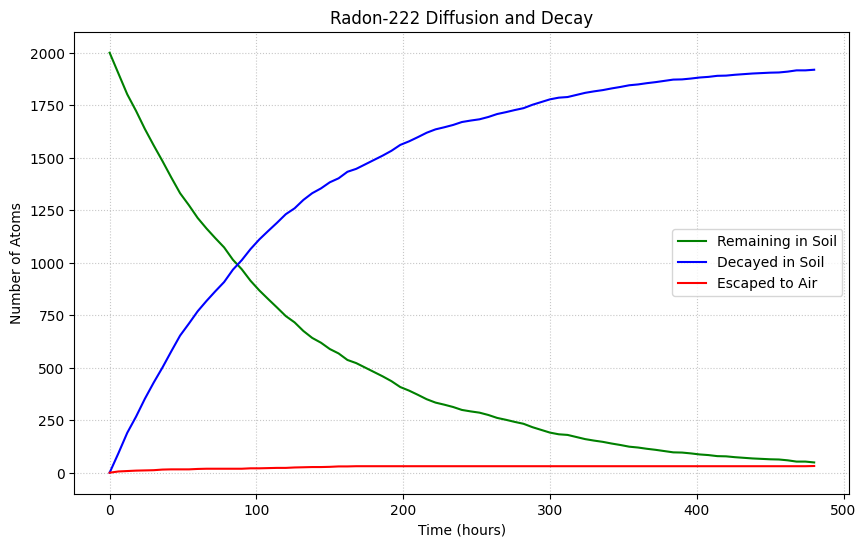

In [20]:
#write code for exercise 3 here
import numpy as np
import matplotlib.pyplot as plt

N_atoms = 2000
half_life_hrs = 3.82 * 24 
dt = 6                     
total_time = 480           
L = 101
limit = L // 2

p_decay = 1 - 2**(-dt / half_life_hrs)

# Randomly distribute atoms in the grid
positions = np.random.randint(-limit, limit + 1, size=(N_atoms, 2))

times = np.arange(0, total_time + dt, dt)
remaining_soil, decayed_in_soil, escaped_to_air = [], [], []

n_decayed = 0
n_escaped = 0
active_mask = np.ones(N_atoms, dtype=bool)

for t in times:
    remaining_soil.append(np.sum(active_mask))
    decayed_in_soil.append(n_decayed)
    escaped_to_air.append(n_escaped)
    
    indices = np.where(active_mask)[0]
    
    for idx in indices:
        if np.random.random() < p_decay:
            # Atom decays and stays in soil
            n_decayed += 1
            active_mask[idx] = False
        else:
            # Random walk movement
            dx, dy = [(0, 1), (0, -1), (-1, 0), (1, 0)][np.random.randint(0, 4)]
            new_x = positions[idx, 0] + dx
            new_y = positions[idx, 1] + dy
            
            # Top boundary check: escape to atmosphere
            if new_y > limit:
                n_escaped += 1
                active_mask[idx] = False
            # Reflecting boundaries for sides and bottom
            elif -limit <= new_x <= limit and -limit <= new_y <= limit:
                positions[idx] = [new_x, new_y]

plt.figure(figsize=(10, 6))
plt.plot(times, remaining_soil, label='Remaining in Soil', color='green')
plt.plot(times, decayed_in_soil, label='Decayed in Soil', color='blue')
plt.plot(times, escaped_to_air, label='Escaped to Air', color='red')

plt.title("Radon-222 Diffusion and Decay")
plt.xlabel("Time (hours)")
plt.ylabel("Number of Atoms")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Was having a lot of trouble with this one I had a decent base but it was not working so I used some help from gemini to help put it all together and see what I had to fix.